In [9]:
import numpy as np # Library for numerical operations
import pandas as pd # Library for data manipulation and analysis

from sklearn.preprocessing import LabelEncoder, StandardScaler # For encoding categorical features and scaling numerical features
from sklearn.model_selection import train_test_split, GridSearchCV # For splitting data and hyperparameter tuning

from sklearn.tree import DecisionTreeClassifier # Decision Tree classification model
from sklearn.ensemble import RandomForestClassifier # Random Forest classification model
from sklearn.linear_model import LogisticRegression # Logistic Regression classification model

from sklearn.metrics import accuracy_score, classification_report # For evaluating model performance

### Data Loading and Initial Inspection

This cell loads the dataset from a CSV file into a pandas DataFrame and displays the first few rows, along with its dimensions (number of rows and columns).

In [19]:
# Load the dataset from the specified CSV file
datasets = pd.read_csv('/content/DOC-20260406-WA0008_')

# Display the first 5 rows of the DataFrame to get a glimpse of the data structure and content
print(datasets.head())

# Print the shape of the DataFrame (number of rows, number of columns) to understand its dimensions
print(datasets.shape)

     N   P   K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0  122  55  74     4.54          58.90      Silt            0.77   
1  112  37  25     7.03          25.98     Sandy            0.66   
2   34  52  39     4.95          27.61      Clay            1.36   
3  126  35  82     7.14          39.97     Loamy            1.09   
4   91  64  51     8.20          33.97     Sandy            0.70   

   Electrical_Conductivity  Temperature  Humidity  Rainfall  Sunlight_Hours  \
0                     0.67        25.31     35.15   1403.58           11.03   
1                     1.94        31.80     54.80   1800.84            4.23   
2                     2.03        15.78     30.88   1336.62           11.45   
3                     0.30        38.23     47.60    480.85            4.71   
4                     2.07        10.04     72.42   2535.23           11.21   

   Wind_Speed   Region  Altitude  Season Irrigation_Type  Fertilizer_Used  \
0        5.98     West      1947  Khari

In [10]:
datasets = pd.read_csv('/content/DOC-20260406-WA0008_')

print(datasets.head())

print(datasets.shape)

     N   P   K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0  122  55  74     4.54          58.90      Silt            0.77   
1  112  37  25     7.03          25.98     Sandy            0.66   
2   34  52  39     4.95          27.61      Clay            1.36   
3  126  35  82     7.14          39.97     Loamy            1.09   
4   91  64  51     8.20          33.97     Sandy            0.70   

   Electrical_Conductivity  Temperature  Humidity  Rainfall  Sunlight_Hours  \
0                     0.67        25.31     35.15   1403.58           11.03   
1                     1.94        31.80     54.80   1800.84            4.23   
2                     2.03        15.78     30.88   1336.62           11.45   
3                     0.30        38.23     47.60    480.85            4.71   
4                     2.07        10.04     72.42   2535.23           11.21   

   Wind_Speed   Region  Altitude  Season Irrigation_Type  Fertilizer_Used  \
0        5.98     West      1947  Khari

In [11]:

datasets = pd.read_csv('/content/DOC-20260406-WA0008_')

# Display the first 5 rows of the DataFrame to get a glimpse of the data
print(datasets.head())

# Print the shape of the DataFrame (number of rows, number of columns)
print(datasets.shape)

     N   P   K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0  122  55  74     4.54          58.90      Silt            0.77   
1  112  37  25     7.03          25.98     Sandy            0.66   
2   34  52  39     4.95          27.61      Clay            1.36   
3  126  35  82     7.14          39.97     Loamy            1.09   
4   91  64  51     8.20          33.97     Sandy            0.70   

   Electrical_Conductivity  Temperature  Humidity  Rainfall  Sunlight_Hours  \
0                     0.67        25.31     35.15   1403.58           11.03   
1                     1.94        31.80     54.80   1800.84            4.23   
2                     2.03        15.78     30.88   1336.62           11.45   
3                     0.30        38.23     47.60    480.85            4.71   
4                     2.07        10.04     72.42   2535.23           11.21   

   Wind_Speed   Region  Altitude  Season Irrigation_Type  Fertilizer_Used  \
0        5.98     West      1947  Khari

### Data Preprocessing - Label Encoding Categorical Features

This cell identifies categorical columns (columns with `object` data type) in the dataset and applies `LabelEncoder` to convert their string values into numerical representations. This is a necessary step for most machine learning algorithms that operate on numerical data. The encoders are stored in a dictionary for potential inverse transformation later.

In [12]:
label_encoders = {}

for column in datasets.columns:
    if datasets[column].dtype == 'object':
        le = LabelEncoder()
        datasets[column] = le.fit_transform(datasets[column])
        label_encoders[column] = le

### Data Splitting and Feature Scaling

This cell prepares the data for model training by separating features (X) from the target variable (Y). It then splits the data into training and testing sets to evaluate model performance on unseen data. Finally, it scales the numerical features using `StandardScaler` to normalize their ranges, which is crucial for many machine learning algorithms.

In [20]:
label_encoders = {} # Dictionary to store label encoders for each categorical column

# Iterate through each column in the dataset
for column in datasets.columns:
    # Check if the column's data type is 'object' (indicating a categorical feature)
    if datasets[column].dtype == 'object':
        le = LabelEncoder() # Initialize a new LabelEncoder
        # Fit the encoder to the column's unique values and transform the column in place
        datasets[column] = le.fit_transform(datasets[column])
        label_encoders[column] = le # Store the fitted encoder in the dictionary

In [13]:
X = datasets.drop("Recommended_Crop", axis=1)

Y = datasets["Recommended_Crop"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Model Training and Initial Evaluation

This section trains three different classification models: Decision Tree, Random Forest, and Logistic Regression. Each model is trained on the preprocessed training data (`X_train`, `Y_train`) and then used to make predictions on the test set (`X_test`). The accuracy of each model is calculated and printed to provide an initial comparison of their performance.

In [21]:
X = datasets.drop("Recommended_Crop", axis=1) # Features: all columns except 'Recommended_Crop'
Y = datasets["Recommended_Crop"] # Target variable: 'Recommended_Crop'

# Split the data into training and testing sets
# test_size=0.2 means 20% of data for testing, 80% for training
# random_state=42 ensures reproducibility of the split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler() # Initialize StandardScaler for feature scaling

# Fit the scaler on the training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# Decision Tree

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, Y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(Y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)



# Random Forest

rf_model = RandomForestClassifier()

rf_model.fit(X_train, Y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(Y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)



# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, Y_train)

y_pred_lr = lr_model.predict(X_test)

acc_lr = accuracy_score(Y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Decision Tree Accuracy: 0.8015
Random Forest Accuracy: 0.805
Logistic Regression Accuracy: 0.68


### Accuracy Comparison Visualization

This cell generates a bar graph to visually compare the accuracy of the three trained models: Decision Tree, Random Forest, and Logistic Regression. This visualization helps in quickly identifying which model performed best on the initial evaluation.

In [22]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier() # Initialize Decision Tree model
dt_model.fit(X_train, Y_train) # Train the model on the training data
y_pred_dt = dt_model.predict(X_test) # Make predictions on the test data
acc_dt = accuracy_score(Y_test, y_pred_dt) # Calculate accuracy
print("Decision Tree Accuracy:", acc_dt)

# Random Forest Classifier
rf_model = RandomForestClassifier() # Initialize Random Forest model
rf_model.fit(X_train, Y_train) # Train the model on the training data
y_pred_rf = rf_model.predict(X_test) # Make predictions on the test data
acc_rf = accuracy_score(Y_test, y_pred_rf) # Calculate accuracy
print("Random Forest Accuracy:", acc_rf)

# Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000) # Initialize Logistic Regression model (increase max_iter for convergence)
lr_model.fit(X_train, Y_train) # Train the model on the training data
y_pred_lr = lr_model.predict(X_test) # Make predictions on the test data
acc_lr = accuracy_score(Y_test, y_pred_lr) # Calculate accuracy
print("Logistic Regression Accuracy:", acc_lr)

Decision Tree Accuracy: 0.798
Random Forest Accuracy: 0.806
Logistic Regression Accuracy: 0.68


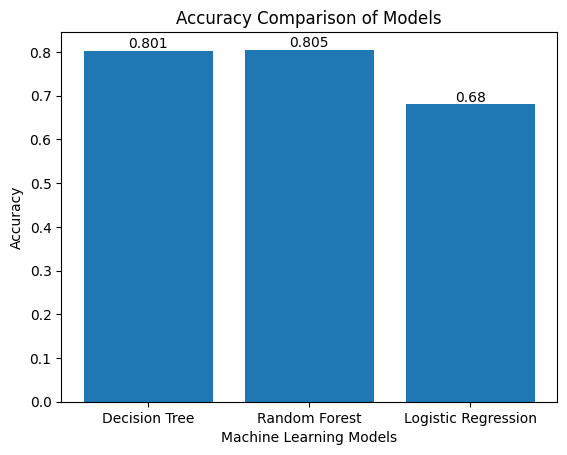

In [15]:
# ==============================
# Accuracy Comparison Graph
# ==============================

import matplotlib.pyplot as plt

# Model Names
models = ['Decision Tree', 'Random Forest', 'Logistic Regression']

# Accuracy Values
accuracies = [acc_dt, acc_rf, acc_lr]

# Create Bar Graph
plt.figure()

plt.bar(models, accuracies)

# Labels
plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison of Models")

# Show Accuracy Values on Bars
for i in range(len(models)):
    plt.text(i, accuracies[i], str(round(accuracies[i], 3)),
             ha='center', va='bottom')

# Show Graph
plt.show()

### Hyperparameter Tuning with GridSearchCV

This cell performs hyperparameter tuning using `GridSearchCV` on the best performing model (Decision Tree in this case). It defines a grid of hyperparameters to search through and uses cross-validation to find the optimal combination that yields the highest accuracy. The best parameters and the final trained model are then extracted.

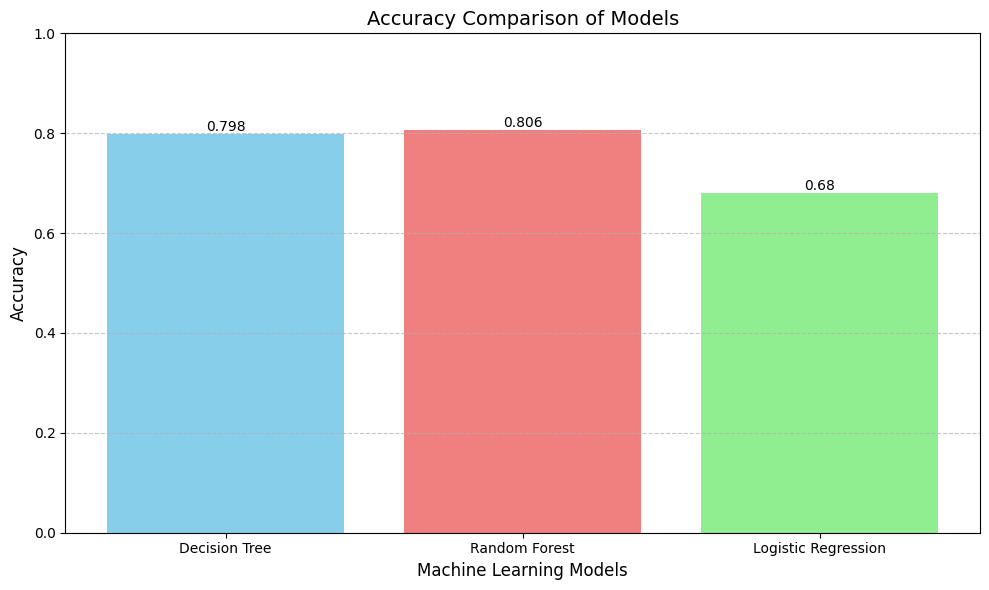

In [23]:
# ==============================
# Accuracy Comparison Graph
# ==============================

import matplotlib.pyplot as plt # Import matplotlib for plotting

# Model Names for the x-axis
models = ['Decision Tree', 'Random Forest', 'Logistic Regression']

# Accuracy Values for the y-axis
accuracies = [acc_dt, acc_rf, acc_lr]

plt.figure(figsize=(10, 6)) # Create a new figure with a specified size
plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen']) # Create a bar chart

# Add labels and title for clarity
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy Comparison of Models", fontsize=14)

# Display accuracy values on top of each bar
for i in range(len(models)):
    plt.text(i, accuracies[i], str(round(accuracies[i], 3)),
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy values
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the graph

In [16]:
best_model_name = "Decision Tree"
if best_model_name == "Decision Tree":

    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    grid = GridSearchCV(
        DecisionTreeClassifier(),
        param_grid,
        cv=3,
        scoring='accuracy'
    )



elif best_model_name == "Random Forest":

    param_grid = {
        'n_estimators': [100, 200],
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 10, 20]
    }

    grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        cv=3,
        scoring='accuracy'
    )



else:

    param_grid = {
        'C': [0.1, 1, 10]
    }

    grid = GridSearchCV(
        LogisticRegression(max_iter=1000),
        param_grid,
        cv=3,
        scoring='accuracy'
    )


# Perform Tuning

grid.fit(X_train, Y_train)

final_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)


Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


### Final Model Evaluation and Classification Report

This cell evaluates the performance of the `final_model` (the best model found after hyperparameter tuning) on the test set. It calculates and prints the overall accuracy and a detailed classification report, which includes precision, recall, f1-score, and support for each class, providing a comprehensive view of the model's performance.

In [24]:
best_model_name = "Decision Tree" # Specifies the model to tune based on previous comparison

# Define hyperparameter grid based on the chosen best model
if best_model_name == "Decision Tree":
    param_grid = {
        'criterion': ['gini', 'entropy'], # Splitting criterion
        'max_depth': [None, 5, 10, 15], # Maximum depth of the tree
        'min_samples_split': [2, 5], # Minimum samples required to split an internal node
        'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
    }
    base_model = DecisionTreeClassifier()
elif best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [100, 200], # Number of trees in the forest
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 10, 20]
    }
    base_model = RandomForestClassifier()
else: # Logistic Regression
    param_grid = {
        'C': [0.1, 1, 10] # Inverse of regularization strength
    }
    base_model = LogisticRegression(max_iter=1000)

# Initialize GridSearchCV
# cv=3 for 3-fold cross-validation
# scoring='accuracy' to optimize for accuracy
grid = GridSearchCV(
    base_model,
    param_grid,
    cv=3,
    scoring='accuracy'
)

# Perform the grid search (hyperparameter tuning) on the training data
grid.fit(X_train, Y_train)

final_model = grid.best_estimator_ # Get the best model found by GridSearchCV

print("\nBest Parameters:", grid.best_params_) # Print the optimal hyperparameters


Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [17]:
y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(Y_test, y_pred_final)

print("\nFinal Tuned Accuracy:", final_accuracy)

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_final))


Final Tuned Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.24      0.23        80
           1       0.46      0.65      0.54        60
           2       0.12      0.07      0.09        43
           3       0.89      0.87      0.88       243
           4       0.11      0.10      0.10        72
           5       0.11      0.14      0.12        36
           6       0.95      0.96      0.95       736
           7       0.86      0.85      0.86       231
           8       0.09      0.05      0.06        22
           9       0.88      0.86      0.87       477

    accuracy                           0.80      2000
   macro avg       0.47      0.48      0.47      2000
weighted avg       0.80      0.80      0.80      2000



### Sample Prediction

This cell demonstrates how to use the trained `final_model` to make a prediction on a new, single sample. It takes the first sample from the original feature set, reshapes it for prediction, scales it using the same scaler fitted on the training data, makes a prediction, and then decodes the numerical prediction back into the original crop name using the stored `LabelEncoder`.

In [25]:
y_pred_final = final_model.predict(X_test) # Make predictions on the test set using the final tuned model

final_accuracy = accuracy_score(Y_test, y_pred_final) # Calculate the accuracy of the final model

print("\nFinal Tuned Accuracy:", final_accuracy) # Print the final accuracy

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_final)) # Print a detailed classification report


Final Tuned Accuracy: 0.797

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.24      0.23        80
           1       0.43      0.62      0.50        60
           2       0.11      0.05      0.06        43
           3       0.90      0.86      0.88       243
           4       0.09      0.08      0.09        72
           5       0.10      0.14      0.12        36
           6       0.95      0.96      0.95       736
           7       0.86      0.85      0.85       231
           8       0.06      0.05      0.05        22
           9       0.88      0.86      0.87       477

    accuracy                           0.80      2000
   macro avg       0.46      0.47      0.46      2000
weighted avg       0.80      0.80      0.80      2000



In [18]:
# Get one sample
sample_input = X.iloc[0].values   # if X is DataFrame

# Reshape
sample_input = sample_input.reshape(1, -1)

# Scale (if you used scaler earlier)
sample_input = scaler.transform(sample_input)

# Predict
prediction = final_model.predict(sample_input)

# Decode label
crop_label_encoder = label_encoders["Recommended_Crop"]
predicted_crop = crop_label_encoder.inverse_transform(prediction)

print("\nPredicted Crop:", predicted_crop[0])


Predicted Crop: Sugarcane


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
# Get one sample from the original feature set (X) for prediction
sample_input = X.iloc[0].values   # Use .values to get the numpy array from a Series/DataFrame row

# Reshape the sample input to be a 2D array (1 sample, n features) as expected by the model
sample_input = sample_input.reshape(1, -1)

# Scale the sample input using the same StandardScaler that was fitted on the training data
sample_input = scaler.transform(sample_input)

# Make a prediction using the final trained model
prediction = final_model.predict(sample_input)

# Retrieve the LabelEncoder used for the 'Recommended_Crop' column
crop_label_encoder = label_encoders["Recommended_Crop"]
# Decode the numerical prediction back into the original crop name
predicted_crop = crop_label_encoder.inverse_transform(prediction)

print("\nPredicted Crop:", predicted_crop[0]) # Print the predicted crop name


Predicted Crop: Sugarcane


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
